In [1]:
# By Britney T Forsyth
# Description: Script to analyze phenograph classification results.

In [2]:
import os 
os.environ['R_HOME'] = '/lila/home/forsythb/anaconda3/envs/scrna/lib/R'

In [3]:
import rpy2

In [4]:
print(rpy2.__version__)

3.5.11


In [5]:
import rpy2.rinterface

In [6]:
import rpy2.robjects

In [7]:
import os

# Get the R home directory from the R_HOME environment variable
r_home = os.environ.get('R_HOME')
print("R home directory:", r_home)

R home directory: /lila/home/forsythb/anaconda3/envs/scrna/lib/R


In [8]:
# Import packages
import numpy as np
import pandas as pd
import scanpy as sc
import re
import os
import sys
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import matplotlib
import milopy

In [9]:
import milopy.core as milo
import milopy.plot as milopl

In [10]:
# Read in adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.probabilities.leiden.h5ad')

In [11]:
adata

AnnData object with n_obs × n_vars = 52800 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'Early NET', 'Enterocyte-like', 'Fetal Progenitor', 'Goblet-like', 'ISC-like', 'Injury Repair', 'TA-like', 'Cell State', 'leiden_res_.25', 'leiden_res_.5', 'leiden_res_1', 'leiden_res_0.1'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'counts', 'without_log'

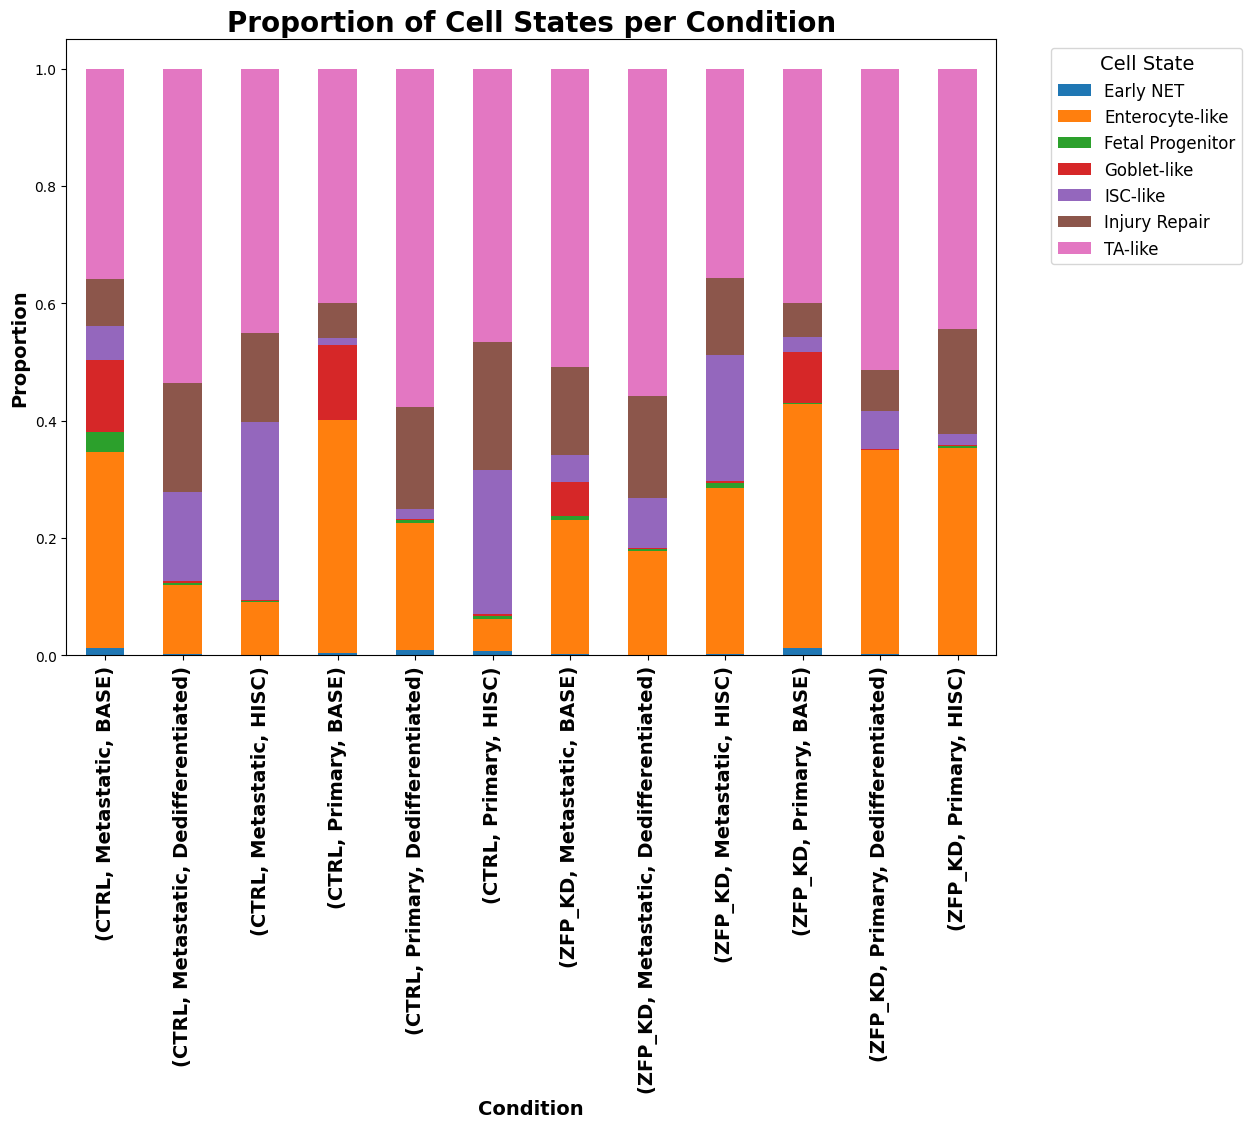

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by unique combinations of conditions and Cell States, and count occurrences
condition_counts = adata.obs.groupby(['ZFP_Expression', 'Tumor_Site', 'Culture_Media', 'Cell State']).size().unstack(fill_value=0)

# Calculate proportion by dividing each count by the total count per condition
condition_proportions = condition_counts.div(condition_counts.sum(axis=1), axis=0)

# Plot stacked bar plot with bold labels and rotated x-axis labels
ax = condition_proportions.plot(kind='bar', stacked=True, figsize=(12, 8))

# Add labels and legend with bold font
plt.title('Proportion of Cell States per Condition', fontsize=20, weight="bold")
plt.xlabel('Condition', fontsize=14, weight="bold")
plt.ylabel('Proportion', fontsize=14, weight="bold")
plt.legend(title='Cell State', fontsize=12, title_fontsize='14')#, labelspacing=0.5)

# Set labels for each bar in bold and rotate x-axis labels
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize('14')
    
# Place legend outside of the plot
plt.legend(title='Cell State', fontsize=12, title_fontsize='14', labelspacing=0.5, bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()


In [12]:
# Build the KNN graph
del adata.obsm['X_diffmap']
d = 30
k = 30
sc.pp.neighbors(adata, n_neighbors=k, n_pcs=d)

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Construct neighborhoods
milo.make_nhoods(adata, prop=0.1)

In [14]:
# Count cells in neighborhood
milo.count_nhoods(adata, sample_col="Sample")

In [15]:
# Differential abundance testing
adata.obs["ZFP_Expression_continuous"] = adata.obs["ZFP_Expression"].cat.codes
#adata.obs["ZFP_Expression_continuous"].value_counts()
milo.DA_nhoods(adata, design="~ZFP_Expression_continuous")

In [16]:
# Differential abundance testing
adata.obs["ZFP_Expression_continuous"].value_counts()

ZFP_Expression_continuous
1    36371
0    16429
Name: count, dtype: int64

In [17]:
# Visualize results by cell type
milopy.utils.annotate_nhoods(adata, anno_col='Cell State')

In [18]:
adata.uns['nhood_adata'].obs.loc[adata.uns['nhood_adata'].obs["nhood_annotation_frac"] < 0.75, "nhood_annotation"] = "Mixed"

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


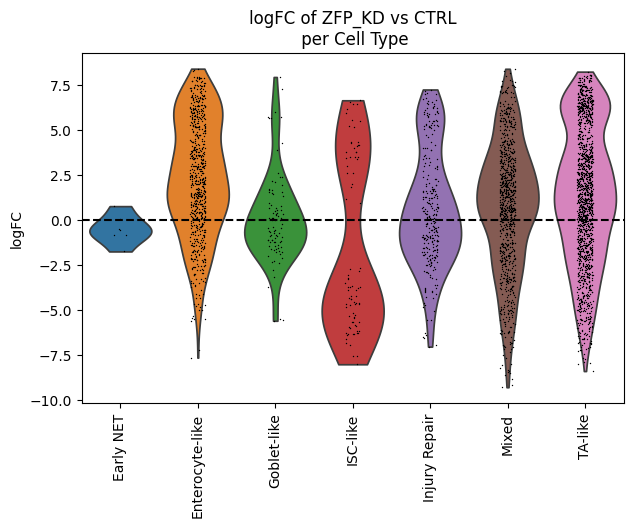

In [19]:
sc.pl.violin(adata.uns['nhood_adata'], "logFC", groupby="nhood_annotation", rotation=90, show=False);
plt.axhline(y=0, color='black', linestyle='--');
plt.title('logFC of ZFP_KD vs CTRL\n per Cell Type')
plt.show()

In [23]:
order = ['ISC-like', 'TA-like', 
         'Goblet-like', 'Enterocyte-like', 
         'Injury Repair', 'Fetal Progenitor', 'Early NET'
         ]
adata.obs['Cell State'] = adata.obs.loc[:,'Cell State'].cat.reorder_categories(order)

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


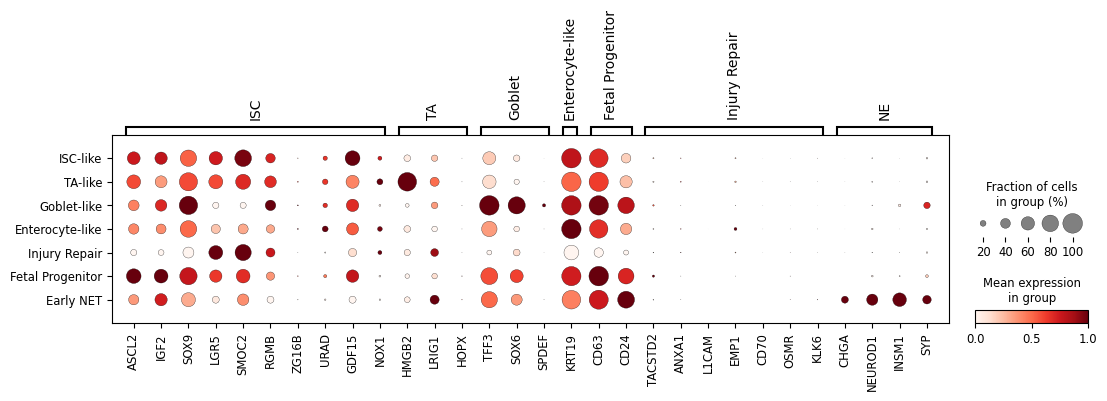

In [27]:
markers = {'ISC': ['ASCL2', 'IGF2', 'SOX9', 'LGR5', 'SMOC2', 'RGMB', 'ZG16B', 'URAD', 'GDF15', 'NOX1'],
           'TA': ['HMGB2', 'LRIG1', 'HOPX'],
           'Goblet': ['TFF3', 'SOX6', 'SPDEF'],
           'Enterocyte-like': ['KRT19'],
           'Fetal Progenitor': ['CD63', 'CD24'], 
           'Injury Repair': ['TACSTD2', 'ANXA1', 'L1CAM', 'EMP1', 'CD70', 'OSMR', 'KLK6'], 
           'NE': ['CHGA', 'NEUROD1', 'INSM1', 'SYP'],
          }
sc.pl.dotplot(adata, markers, groupby=['Cell State'], standard_scale='var')#, dendrogram=True, standard_scale='var')

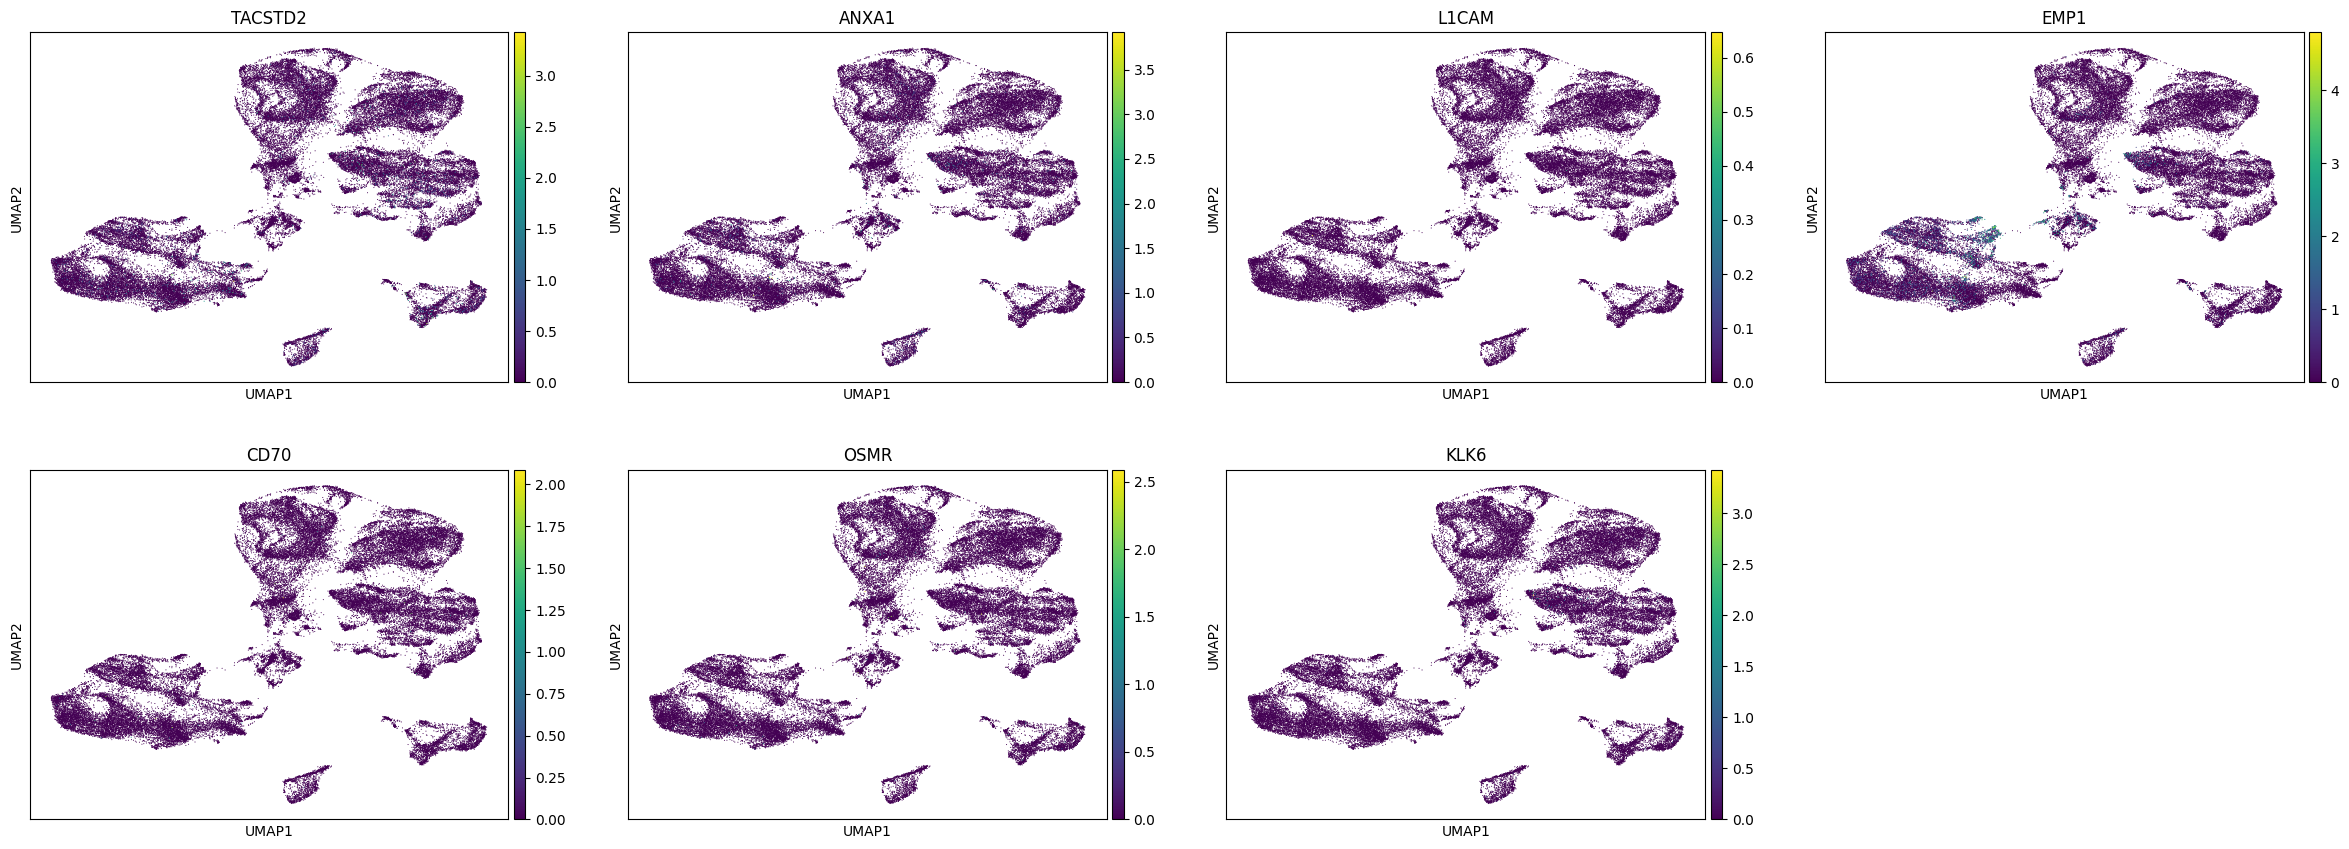

In [28]:
sc.pl.umap(adata, 
          color=['TACSTD2', 'ANXA1', 'L1CAM', 'EMP1', 'CD70', 'OSMR', 'KLK6'])